   Training Size (%)   MSE Error
0               10.0  399.773140
1               20.0  334.940565
2               30.0  327.078756
3               40.0  325.790166
4               50.0  324.611010
5               60.0  323.987933
6               70.0  323.218977
7               80.0  322.466506
8               90.0  324.940797
9              100.0  323.741509


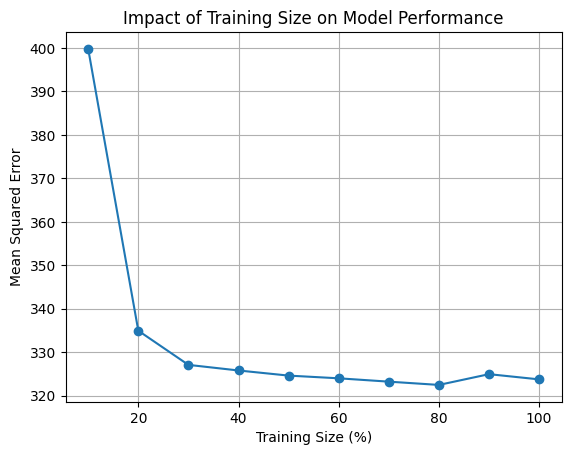

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Step 1: Generate dataset
N = 1000   # you can change this
X, y = make_regression(n_samples=N, n_features=1, noise=20, random_state=42)

# Split into train and test (N/10 for test)
split = int(0.9 * N)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Step 2: Create subsets (10% to 100%)
sizes = np.arange(0.1, 1.1, 0.1)
scores = []

# Step 3 & 4: Train model and evaluate
for s in sizes:
    subset_size = int(s * len(X_train))
    
    X_sub = X_train[:subset_size]
    y_sub = y_train[:subset_size]
    
    # Create model
    model = LinearRegression()
    model.fit(X_sub, y_sub)
    
    # Calculate R² score on test data
    r2 = model.score(X_test, y_test)
    scores.append(r2)

# Convert to DataFrame (using pandas)
df = pd.DataFrame({
    "Training Size (%)": sizes * 100,
    "R² Score": scores
})

print(df)

# Step 5: Plot graph
plt.figure()
plt.plot(df["Training Size (%)"], df["R² Score"], marker='o')
plt.xlabel("Training Size (%)")
plt.ylabel("R² Score")
plt.title("Impact of Training Size on Model Performance")
plt.grid()

plt.show()